<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_162_mod2_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**
Module 2, MNIST Data;
CSC 162, Fall 2025;
November 15, 2025


**DUE: Monday, NOV. 13, 2025**

**INSTRUCTIONS:**

**Overview**

*In this assignment, you will:*

1. Load and preprocess the EMNIST Letters dataset (a handwritten alphabet dataset).

2. Build a Convolutional Neural Network (CNN) using TensorFlow and Keras.

3. Train and evaluate your model on the dataset.

4. Visualize some predictions from the test set.

CNNs are effective in image processing and classification tasks because they automatically learn hierarchical features from raw pixel data. In this task, you will practice using layers such as convolution, pooling, and activation functions to extract meaningful patterns from handwritten letters.

1. If needed, review the following lecture:

2. Video - Introduction to CNNs Using Google Colab Lecture: https://youtu.be/7L0FXpE6Vns

**TASK INSTRUCTIONS:**

**1. Data Loading and Preprocessing**
Objective: Load the EMNIST Letters dataset using TensorFlow Datasets and preprocess the images.



**Objective:** Load the EMNIST Letters dataset using TensorFlow Datasets and preprocess the images.

**Requirements:**

1. Normalize pixel values so that they are between 0 and 1.

2. Reshape images to include a channel dimension (28×28×1) for grayscale.

3. Split the dataset into training and testing sets.

**Starter Code for Loading EMNIST Data:**

**Import packages.**

In [9]:
#python
# Import necessary packages
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

**Load the EMNIST dataset.**

In [20]:
# Load the EMNIST Letters dataset.
# This dataset contains 145,600 training images and 14,400 testing images (grayscale, 28x28).
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # returns tuple (img, label)
    with_info=True
)


**Preprocess the images.**

In [21]:
# Function to preprocess the images
def preprocess(image, label):
    # Convert image dtype to float32 and scale pixels to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Reshape image to (28, 28, 1) for CNN input
    image = tf.expand_dims(image, -1)
    # Adjust label: EMNIST Letters dataset labels are in the range [1, 26]; subtract 1 to get [0, 25]
    label = label - 1
    return image, label

**Apply the preprocessing function** (to the train and test datasets).

In [22]:
# Apply the preprocessing function to the train and test datasets.
ds_train = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

**Batch and prefetch the datasets** (for training efficiency).

In [23]:
# Batch and prefetch the datasets for training efficiency.
batch_size = 64
ds_train = ds_train.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

**2. Build the CNN Model**
Objective: Create a CNN using TensorFlow Keras.

**Objective:** Create a CNN using TensorFlow Keras.

**Requirements:**

1. Use at least two Conv2D layers with appropriate filter sizes (e.g., 32 and 64 filters) and a kernel size (commonly 3×3).

2. Include MaxPooling2D layers following each convolution to reduce feature map dimensions.

3. Add activation functions (e.g., ReLU) after convolution layers.

4. Flatten feature maps and add one or more Dense (fully connected) layers.

5. Use a final Dense layer with softmax activation to output predictions over 26 classes (representing A–Z).


In [28]:
# Build a Sequential CNN model for Fashion MNIST
full_mnist_model = models.Sequential([
    #Convolutional layer: Applies 32 filters of size 3x3 using ReLU activation.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    #Max pooling layer: Reduces spatial dimensions by taking the max value in 2x2 windows.
    layers.MaxPooling2D((2, 2)),

    #Second convolutional layer: Uses 64 filters to extract more complex features.
    layers.Conv2D(64, (3, 3), activation='relu'),

    #Second max pooling layer.
    layers.MaxPooling2D((2, 2)),

    #Flatten the feature maps into a 1D vector.
    layers.Flatten(),

    #Dense layer: Learns a complex representation from features.
    layers.Dense(64, activation='relu'),

    #Output layer: Produces 26 class probabilities via softmax activation.
    layers.Dense(26, activation='softmax')
])



**3. Model Compilation and Training**

**Steps:**

1. Compile the model using the Adam optimizer and the sparse categorical cross-entropy loss (since labels are integers in the range [0, 25]).

2. Train your model for about 10–20 epochs.

3. Use part of the training data for validation (e.g., set validation_split if using non-dataset pipeline or create a separate validation set).

1. Compile the model

In [29]:
#Compile the model with the Adam optimizer and sparse categorical cross-entropy loss
full_mnist_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])



2. Validation (using part of the training data).

In [32]:
#Python
#First, split the data into train and validation before the doing the model fit step (using 10% of data as validation).
TRAIN_SIZE = int(0.9 * ds_info.splits['train'].num_examples) # 90% for training
VALIDATION_SIZE = ds_info.splits['train'].num_examples - TRAIN_SIZE # 10% for validation

ds_train_subset = ds_train.take(TRAIN_SIZE)
ds_validation_subset = ds_train.skip(TRAIN_SIZE).take(VALIDATION_SIZE)

3. Train the model (10-20 epochs).

In [33]:
#Train the full MNIST model for 10 epochs (using 10% of data as validation); pass the validation subset in to the model "fit" using the validation_data instead of validation_split (because I already split the data prior to the "fit" command in the model.)
#full_mnist_model.fit(ds_train, epochs=10, validation_split=0.1)

full_mnist_model.fit(ds_train_subset, epochs=10, validation_data=ds_validation_subset)

Epoch 1/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 87s 61ms/step - accuracy: 0.6852 - loss: 1.0514
Epoch 2/10
   2/1388 ━━━━━━━━━━━━━━━━━━━━ 1:17 56ms/step - accuracy: 0.8555 - loss: 0.4811

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1388/1388 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - accuracy: 0.8965 - loss: 0.3184
Epoch 3/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.9185 - loss: 0.2484
Epoch 4/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.9283 - loss: 0.2119
Epoch 5/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9370 - loss: 0.1834
Epoch 6/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.9408 - loss: 0.1649
Epoch 7/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - accuracy: 0.9468 - loss: 0.1456
Epoch 8/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.9524 - loss: 0.1306
Epoch 9/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - accuracy: 0.9563 - loss: 0.1195
Epoch 10/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 70s 51ms/step - accuracy: 0.9584 - loss: 0.1093


In [34]:
#Print the model summary to review the architecture and number of parameters
full_mnist_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 368,912 (1.41 MB)

 Trainable params: 122,970 (480.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 245,942 (960.71 KB)

**4. Evaluation and Visualization**

**Tasks:**

1. Evaluate your trained model using the test set and report the test accuracy.

2. Display a few sample test images with their predicted class labels using Matplotlib.

3. Comment on your model’s performance and any observations.

1a. Evaluate trained model on test set.

In [38]:
#Evaluate the model on the test set
test_loss_f, test_acc_f = full_mnist_model.evaluate(ds_test, verbose=2)
print("Full MNIST Test Accuracy:", test_acc_f)

232/232 - 5s - 21ms/step - accuracy: 0.9114 - loss: 0.2788
Full MNIST Test Accuracy: 0.9113513231277466


1b. Report the test accuracy.

2. Display test images with predicted class labels.

In [39]:
# Make a prediction on a random sample image from the Fashion MNIST test set
sample_index_f = np.random.randint(0, ds_test.shape[0])
sample_image_f = ds_test[sample_index_f]
prediction_f = full_mnist_model.predict(sample_image_f[np.newaxis, ...])
predicted_class_f = np.argmax(prediction_f, axis=1)
print("Predicted class for Full MNIST sample:", predicted_class_f[0])

AttributeError: '_PrefetchDataset' object has no attribute 'shape'

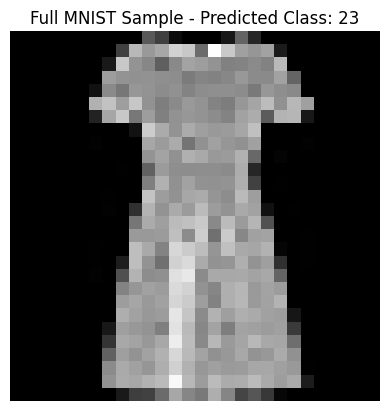

In [37]:
# Display the sample image with predicted class
plt.imshow(sample_image_f.reshape(28,28), cmap='gray')
plt.title("Full MNIST Sample - Predicted Class: {}".format(predicted_class_f[0]))
plt.axis('off')
plt.show()

3. Comment on my model's performance (and any observations).

COMMENTS:

**5. Documentation and Submission**

**1. Documentation:** Ensure that your Colab notebook is well-documented. Include comments in each code cell explaining what each section of code is doing.


**2. File Submission:** When you have completed the assignment, save your Google Colab notebook as a .ipynb file and upload it to Brightspace as your assignment submission. (Example SmithMod02.ipynb)